# Instruction (Read this)
- Use this template to develop your project. Do not change the steps. 
- For each step, you may add additional cells if needed.
- But remove <b>unnecessary</b> cells to ensure the notebook is readable.
- Marks will be <b>deducted</b> if the notebook is cluttered or difficult to follow due to excess or irrelevant content.
- <b>Briefly</b> describe the steps in the "Description:" field.
- <b>Do not</b> submit the dataset. 
- The submitted jupyter notebook will be executed using the uploaded dataset in eLearn.

# Group Information

Group No:

- Member 1: CH'NG BAO SHENG (23302782)
- Member 2: LIM YONG ZHOU (23302902)
- Member 3: JEFFRY SOO YU ZHEN (23304759)

# Import Necessary Libraries

## Core Data Handling

In [1]:
import pandas as pd # for data manipulation
import warnings # for warning control
warnings.filterwarnings('ignore') # ignore warning messages


## Numerics and Array Operations

In [2]:
import numpy as np # for numerical operations

## Machine Learning Algorithms and Utilities

In [3]:
from sklearn.linear_model import LogisticRegression # for Logistic Regression classifier
from sklearn.svm import SVC # for Support Vector Machine classifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV # for data splits, CV, and tuning
from sklearn.preprocessing import StandardScaler # for feature scaling
from sklearn.feature_selection import SequentialFeatureSelector # for Sequential Feature Selection
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
) # for model evaluation metrics
import copy # for deep copying SVM estimators during grid search


## Visualization

In [4]:
import matplotlib.pyplot as plt # for plotting graphs
import seaborn as sns # for enhanced data visualization

# Load the Dataset

In [5]:
# Define column names based on the Dermatology dataset README
columns = [
    'erythema',
    'scaling',
    'definite_borders',
    'itching',
    'koebner_phenomenon',
    'polygonal_papules',
    'follicular_papules',
    'oral_mucosal_involvement',
    'knee_and_elbow_involvement',
    'scalp_involvement',
    'family_history',
    'melanin_incontinence',
    'eosinophils_in_the_infiltrate',
    'PNL_infiltrate',
    'fibrosis_of_the_papillary_dermis',
    'exocytosis',
    'acanthosis',
    'hyperkeratosis',
    'parakeratosis',
    'clubbing_of_the_rete_ridges',
    'elongation_of_the_rete_ridges',
    'thinning_of_the_suprapapillary_epidermis',
    'spongiform_pustule',
    'munro_microabcess',
    'focal_hypergranulosis',
    'disappearance_of_the_granular_layer',
    'vacuolisation_and_damage_of_basal_layer',
    'spongiosis',
    'saw_tooth_appearance_of_retes',
    'follicular_horn_plug',
    'perifollicular_parakeratosis',
    'inflammatory_mononuclear_infiltrate',
    'band_like_infiltrate',
    'age',
    'class'
]

# Load the dataset without headers and convert '?' missing values to NaN
df = pd.read_csv(
    'Project Datasets/Dermatology/dermatology.csv',
    header=None,
    names=columns,
    na_values='?'
)

# Display the first five rows of the dataset
df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw_tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3


# Exploratory Data Analysis (EDA)

## Initial Analysis of Dataset

In [6]:
print('Dataset dimension:', df.shape) # Display the number of rows and columns
print('Number of features:', df.drop(columns=['class']).shape[1]) # Display the number of input features
print('Columns of features:', df.drop(columns=['class']).columns) # Display all feature column names
print('Target column: class') # Display the target column name

Dataset dimension: (366, 35)
Number of features: 34
Columns of features: Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_in_the_infiltrate', 'PNL_infiltrate',
       'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis',
       'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges',
       'elongation_of_the_rete_ridges',
       'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_of_the_granular_layer',
       'vacuolisation_and_damage_of_basal_layer', 'spongiosis',
       'saw_tooth_appearance_of_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_mononuclear_infiltrate',
       'band_like_infiltrate', 'age'],


## Data Types of Dataset

In [7]:
df.info() # Display column names, data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   erythema                                  366 non-null    int64  
 1   scaling                                   366 non-null    int64  
 2   definite_borders                          366 non-null    int64  
 3   itching                                   366 non-null    int64  
 4   koebner_phenomenon                        366 non-null    int64  
 5   polygonal_papules                         366 non-null    int64  
 6   follicular_papules                        366 non-null    int64  
 7   oral_mucosal_involvement                  366 non-null    int64  
 8   knee_and_elbow_involvement                366 non-null    int64  
 9   scalp_involvement                         366 non-null    int64  
 10  family_history                            366 non

## Descriptive Statistics for Numeric Columns

In [8]:
df.describe() # Display descriptive statistics for numeric columns

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw_tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,...,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,358.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,...,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,36.296089,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,...,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,15.324557,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,25.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,35.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,49.750000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,75.000000,6.000000


# Data Preparation
______________________________________________________________________________________
Description: Missing values, duplicate rows, and outlier considerations are handled before checking the final class distribution and splitting the dataset.

## Data Cleaning

### Handling Missing Values

In [9]:
missing_counts = df.isnull().sum() # Count missing values for each column
missing_counts[missing_counts > 0] # Display only columns with missing values

age    8
dtype: int64

In [10]:
age_median = df['age'].median() # Calculate the median age for imputation
df['age'] = df['age'].fillna(age_median) # Replace missing age values with the median age

print('Median age used for imputation:', age_median) # Display the median value used
print('Total missing values after imputation:', df.isnull().sum().sum()) # Check remaining missing values

Median age used for imputation: 35.0
Total missing values after imputation: 0


### Handling Duplicate Rows

In [11]:
duplicate_count = df.duplicated().sum() # Count duplicate rows in the dataset
print('Number of duplicate rows:', duplicate_count) # Display the number of duplicated rows

# Remove duplicate rows if any are found
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True) # Drop duplicates and reset the index
    print('Duplicates removed. New dataset dimension:', df.shape) # Display new dataset dimension
else:
    print('No duplicate rows were found.') # Inform that no duplicates were found

Number of duplicate rows: 0
No duplicate rows were found.


## Outlier Checking
Most dermatology features are ordinal clinical or histopathological scores from 0 to 3. Therefore, values in this range are valid medical severity levels rather than statistical outliers. Only `age` is inspected separately, and rows are not removed using IQR to avoid deleting valid medical cases from a small dataset.

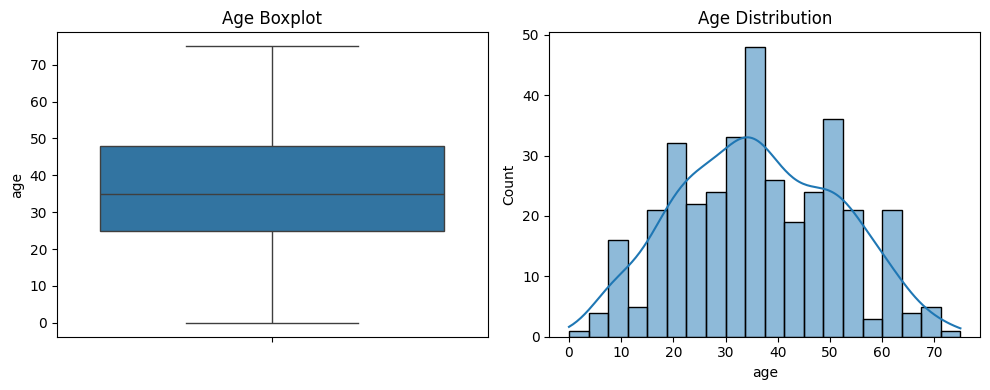

In [12]:
plt.figure(figsize=(10, 4)) # Set the figure size for side-by-side plots

plt.subplot(1, 2, 1) # Create the first subplot for boxplot
sns.boxplot(y=df['age']) # Plot age values to inspect possible outliers
plt.title('Age Boxplot') # Set title for the boxplot

plt.subplot(1, 2, 2) # Create the second subplot for histogram
sns.histplot(df['age'], bins=20, kde=True) # Plot the distribution of age
plt.title('Age Distribution') # Set title for the histogram

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show() # Display the plots

## Class Distribution After Cleaning

In [13]:
# Define class labels based on the Dermatology dataset README
class_names = {
    1: 'psoriasis',
    2: 'seboreic dermatitis',
    3: 'lichen planus',
    4: 'pityriasis rosea',
    5: 'cronic dermatitis',
    6: 'pityriasis rubra pilaris'
}

# Count the number of instances for each disease class after cleaning
class_distribution = df['class'].value_counts().sort_index()

# Convert the class distribution into a DataFrame for clearer display
class_distribution_df = class_distribution.rename_axis('class').reset_index(name='count')

# Map each class number to its disease name
class_distribution_df['disease'] = class_distribution_df['class'].map(class_names)

# Display the final class distribution table before splitting
class_distribution_df

,class,count,disease
0,1,112,psoriasis
1,2,61,seboreic dermatitis
2,3,72,lichen planus
3,4,49,pityriasis rosea
4,5,52,cronic dermatitis
5,6,20,pityriasis rubra pilaris


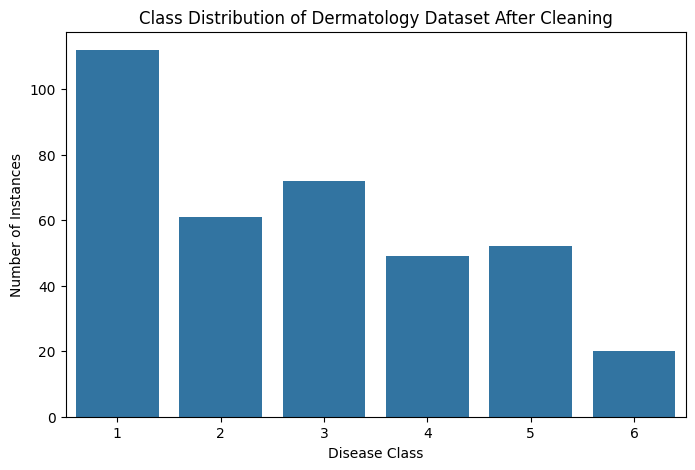

In [14]:
plt.figure(figsize=(8, 5)) # Set the figure size
sns.countplot(data=df, x='class', order=sorted(df['class'].unique())) # Plot the number of records for each class
plt.title('Class Distribution of Dermatology Dataset After Cleaning') # Set the chart title
plt.xlabel('Disease Class') # Set x-axis label
plt.ylabel('Number of Instances') # Set y-axis label
plt.show() # Display the plot

# Split the Dataset
Split the dataset into training, validation, and test sets. Three stratified split ratios are prepared: 80/10/10, 70/15/15, and 60/20/20.

In [15]:
X = df.drop(columns=['class']) # Select all input features
y = df['class'] # Select the multi-class target variable

print('All feature data types:') # Display the data types of all input features
print(X.dtypes.value_counts()) # Count the number of columns for each data type
print('\nTarget classes:', sorted(y.unique())) # Display unique target classes

All feature data types:
int64      33
float64     1
Name: count, dtype: int64

Target classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [16]:
# Split the dataset into 80% training data and 20% temporary data for the 80/10/10 split
x_train_80, x_temp_20_for_80, y_train_80, y_temp_20_for_80 = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Split the temporary 20% data equally into 10% validation data and 10% test data
x_val_10, x_test_10, y_val_10, y_test_10 = train_test_split(
    x_temp_20_for_80,
    y_temp_20_for_80,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_20_for_80
)

# Split the dataset into 70% training data and 30% temporary data for the 70/15/15 split
x_train_70, x_temp_30_for_70, y_train_70, y_temp_30_for_70 = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split the temporary 30% data equally into 15% validation data and 15% test data
x_val_15, x_test_15, y_val_15, y_test_15 = train_test_split(
    x_temp_30_for_70,
    y_temp_30_for_70,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_30_for_70
)

# Split the dataset into 60% training data and 40% temporary data for the 60/20/20 split
x_train_60, x_temp_40_for_60, y_train_60, y_temp_40_for_60 = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

# Split the temporary 40% data equally into 20% validation data and 20% test data
x_val_20, x_test_20, y_val_20, y_test_20 = train_test_split(
    x_temp_40_for_60,
    y_temp_40_for_60,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_40_for_60
)

# Store all explicit split variables in a dictionary for easier looping in later preprocessing steps
split_datasets = {
    '80_10_10': {
        'X_train': x_train_80,
        'X_val': x_val_10,
        'X_test': x_test_10,
        'y_train': y_train_80,
        'y_val': y_val_10,
        'y_test': y_test_10
    },
    '70_15_15': {
        'X_train': x_train_70,
        'X_val': x_val_15,
        'X_test': x_test_15,
        'y_train': y_train_70,
        'y_val': y_val_15,
        'y_test': y_test_15
    },
    '60_20_20': {
        'X_train': x_train_60,
        'X_val': x_val_20,
        'X_test': x_test_20,
        'y_train': y_train_60,
        'y_val': y_val_20,
        'y_test': y_test_20
    }
}

# Display the dimensions of each explicit split dataset
print('80/10/10 split')
print('x_train_80:', x_train_80.shape, 'y_train_80:', y_train_80.shape)
print('x_val_10:', x_val_10.shape, 'y_val_10:', y_val_10.shape)
print('x_test_10:', x_test_10.shape, 'y_test_10:', y_test_10.shape)
print('-' * 50)

print('70/15/15 split')
print('x_train_70:', x_train_70.shape, 'y_train_70:', y_train_70.shape)
print('x_val_15:', x_val_15.shape, 'y_val_15:', y_val_15.shape)
print('x_test_15:', x_test_15.shape, 'y_test_15:', y_test_15.shape)
print('-' * 50)

print('60/20/20 split')
print('x_train_60:', x_train_60.shape, 'y_train_60:', y_train_60.shape)
print('x_val_20:', x_val_20.shape, 'y_val_20:', y_val_20.shape)
print('x_test_20:', x_test_20.shape, 'y_test_20:', y_test_20.shape)

80/10/10 split
x_train_80: (292, 34) y_train_80: (292,)
x_val_10: (37, 34) y_val_10: (37,)
x_test_10: (37, 34) y_test_10: (37,)
--------------------------------------------------
70/15/15 split
x_train_70: (256, 34) y_train_70: (256,)
x_val_15: (55, 34) y_val_15: (55,)
x_test_15: (55, 34) y_test_15: (55,)
--------------------------------------------------
60/20/20 split
x_train_60: (219, 34) y_train_60: (219,)
x_val_20: (73, 34) y_val_20: (73,)
x_test_20: (74, 34) y_test_20: (74,)


In [17]:
# Display the class distribution for each train, validation and test split
for split_name, data in split_datasets.items():
    split_distribution = pd.DataFrame({
        'train': data['y_train'].value_counts().sort_index(),
        'validation': data['y_val'].value_counts().sort_index(),
        'test': data['y_test'].value_counts().sort_index()
    })

    print(f'Class distribution for {split_name} split') # Display split name
    display(split_distribution) # Display the class distribution table for the split

Class distribution for 80_10_10 split


,train,validation,test
class,,,
1,89,11,12
2,49,6,6
3,57,8,7
4,39,5,5
5,42,5,5
6,16,2,2


Class distribution for 70_15_15 split


,train,validation,test
class,,,
1,78,17,17
2,43,9,9
3,50,11,11
4,34,7,8
5,37,8,7
6,14,3,3


Class distribution for 60_20_20 split


,train,validation,test
class,,,
1,67,22,23
2,37,12,12
3,43,14,15
4,29,10,10
5,31,11,10
6,12,4,4


In [18]:
# Use the 70/15/15 split as the default split for the remaining preprocessing examples
X_train = x_train_70 # Default training features
X_val = x_val_15 # Default validation features
X_test = x_test_15 # Default test features
y_train = y_train_70 # Default training target
y_val = y_val_15 # Default validation target
y_test = y_test_15 # Default test target

# Data Preprocessing
Perform data preprocessing such as normalization, standardization, label encoding etc.
______________________________________________________________________________________
Description: Label encoding is not required because all attributes and class labels are already numeric. Standardization is applied after splitting. Each scaler is fitted only on its training set, then applied to the matching validation and test sets to avoid data leakage.

In [19]:
# Create separate StandardScaler objects for each split ratio
scaler_80_10_10 = StandardScaler() # Scaler for 80/10/10 split
scaler_70_15_15 = StandardScaler() # Scaler for 70/15/15 split
scaler_60_20_20 = StandardScaler() # Scaler for 60/20/20 split

# Fit the scaler on 80% training data and transform the matching validation and test data
x_train_80_scaled = scaler_80_10_10.fit_transform(x_train_80) # Fit and transform 80% training features
x_val_10_scaled = scaler_80_10_10.transform(x_val_10) # Transform 10% validation features
x_test_10_scaled = scaler_80_10_10.transform(x_test_10) # Transform 10% test features

# Convert the 80/10/10 scaled arrays back into DataFrames
x_train_80_scaled_df = pd.DataFrame(x_train_80_scaled, columns=X.columns, index=x_train_80.index)
x_val_10_scaled_df = pd.DataFrame(x_val_10_scaled, columns=X.columns, index=x_val_10.index)
x_test_10_scaled_df = pd.DataFrame(x_test_10_scaled, columns=X.columns, index=x_test_10.index)

# Fit the scaler on 70% training data and transform the matching validation and test data
x_train_70_scaled = scaler_70_15_15.fit_transform(x_train_70) # Fit and transform 70% training features
x_val_15_scaled = scaler_70_15_15.transform(x_val_15) # Transform 15% validation features
x_test_15_scaled = scaler_70_15_15.transform(x_test_15) # Transform 15% test features

# Convert the 70/15/15 scaled arrays back into DataFrames
x_train_70_scaled_df = pd.DataFrame(x_train_70_scaled, columns=X.columns, index=x_train_70.index)
x_val_15_scaled_df = pd.DataFrame(x_val_15_scaled, columns=X.columns, index=x_val_15.index)
x_test_15_scaled_df = pd.DataFrame(x_test_15_scaled, columns=X.columns, index=x_test_15.index)

# Fit the scaler on 60% training data and transform the matching validation and test data
x_train_60_scaled = scaler_60_20_20.fit_transform(x_train_60) # Fit and transform 60% training features
x_val_20_scaled = scaler_60_20_20.transform(x_val_20) # Transform 20% validation features
x_test_20_scaled = scaler_60_20_20.transform(x_test_20) # Transform 20% test features

# Convert the 60/20/20 scaled arrays back into DataFrames
x_train_60_scaled_df = pd.DataFrame(x_train_60_scaled, columns=X.columns, index=x_train_60.index)
x_val_20_scaled_df = pd.DataFrame(x_val_20_scaled, columns=X.columns, index=x_val_20.index)
x_test_20_scaled_df = pd.DataFrame(x_test_20_scaled, columns=X.columns, index=x_test_20.index)

# Store all explicit scaled variables in a dictionary for easier looping in later model training
scaled_datasets = {
    '80_10_10': {
        'X_train_scaled': x_train_80_scaled_df,
        'X_val_scaled': x_val_10_scaled_df,
        'X_test_scaled': x_test_10_scaled_df,
        'y_train': y_train_80,
        'y_val': y_val_10,
        'y_test': y_test_10,
        'scaler': scaler_80_10_10
    },
    '70_15_15': {
        'X_train_scaled': x_train_70_scaled_df,
        'X_val_scaled': x_val_15_scaled_df,
        'X_test_scaled': x_test_15_scaled_df,
        'y_train': y_train_70,
        'y_val': y_val_15,
        'y_test': y_test_15,
        'scaler': scaler_70_15_15
    },
    '60_20_20': {
        'X_train_scaled': x_train_60_scaled_df,
        'X_val_scaled': x_val_20_scaled_df,
        'X_test_scaled': x_test_20_scaled_df,
        'y_train': y_train_60,
        'y_val': y_val_20,
        'y_test': y_test_20,
        'scaler': scaler_60_20_20
    }
}

# Display the first five rows of the scaled training features for the default 70/15/15 split
x_train_70_scaled_df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw_tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age
273,-0.072286,0.268991,1.576253,-0.343212,-0.678289,-0.462741,-0.299271,-0.448523,2.461330,1.769005,...,-0.474377,1.751751,-0.482668,-0.888264,-0.470526,-0.23858,-0.233493,1.545793,-0.503066,1.348490
317,-0.072286,0.268991,0.485656,-1.239765,0.449256,-0.462741,-0.299271,-0.448523,1.430069,1.769005,...,-0.474377,1.751751,-0.482668,-0.888264,-0.470526,-0.23858,-0.233493,0.181231,-0.503066,0.696036
46,-0.072286,-1.136351,-0.604940,1.449894,2.704347,-0.462741,-0.299271,-0.448523,-0.632453,-0.577447,...,-0.474377,-0.524636,-0.482668,-0.003456,-0.470526,-0.23858,-0.233493,0.181231,-0.503066,0.630791
270,-0.072286,0.268991,-0.604940,-1.239765,0.449256,-0.462741,-0.299271,-0.448523,-0.632453,-0.577447,...,-0.474377,0.613558,-0.482668,1.766158,-0.470526,-0.23858,-0.233493,0.181231,-0.503066,1.674717
256,-0.072286,-1.136351,-0.604940,-1.239765,0.449256,-0.462741,-0.299271,-0.448523,-0.632453,-0.577447,...,-0.474377,0.613558,-0.482668,0.881351,-0.470526,-0.23858,-0.233493,-1.183331,-0.503066,-0.086909


In [20]:
# Store default scaled datasets for easier use in the next preprocessing steps
X_train_scaled_df = x_train_70_scaled_df # Default scaled training features
X_val_scaled_df = x_val_15_scaled_df # Default scaled validation features
X_test_scaled_df = x_test_15_scaled_df # Default scaled test features

## Prepare Datasets for Logistic Regression and SVM
Logistic Regression and SVM are sensitive to feature scale, so the scaled datasets are prepared for both algorithms. The same train, validation and test splits are reused to ensure a fair comparison.

In [21]:
# Prepare explicit scaled datasets for Logistic Regression using 80/10/10 split
lr_x_train_80 = x_train_80_scaled_df # Logistic Regression training features for 80/10/10 split
lr_x_val_10 = x_val_10_scaled_df # Logistic Regression validation features for 80/10/10 split
lr_x_test_10 = x_test_10_scaled_df # Logistic Regression test features for 80/10/10 split
lr_y_train_80 = y_train_80 # Logistic Regression training target for 80/10/10 split
lr_y_val_10 = y_val_10 # Logistic Regression validation target for 80/10/10 split
lr_y_test_10 = y_test_10 # Logistic Regression test target for 80/10/10 split

# Prepare explicit scaled datasets for Logistic Regression using 70/15/15 split
lr_x_train_70 = x_train_70_scaled_df # Logistic Regression training features for 70/15/15 split
lr_x_val_15 = x_val_15_scaled_df # Logistic Regression validation features for 70/15/15 split
lr_x_test_15 = x_test_15_scaled_df # Logistic Regression test features for 70/15/15 split
lr_y_train_70 = y_train_70 # Logistic Regression training target for 70/15/15 split
lr_y_val_15 = y_val_15 # Logistic Regression validation target for 70/15/15 split
lr_y_test_15 = y_test_15 # Logistic Regression test target for 70/15/15 split

# Prepare explicit scaled datasets for Logistic Regression using 60/20/20 split
lr_x_train_60 = x_train_60_scaled_df # Logistic Regression training features for 60/20/20 split
lr_x_val_20 = x_val_20_scaled_df # Logistic Regression validation features for 60/20/20 split
lr_x_test_20 = x_test_20_scaled_df # Logistic Regression test features for 60/20/20 split
lr_y_train_60 = y_train_60 # Logistic Regression training target for 60/20/20 split
lr_y_val_20 = y_val_20 # Logistic Regression validation target for 60/20/20 split
lr_y_test_20 = y_test_20 # Logistic Regression test target for 60/20/20 split

# Prepare explicit scaled datasets for SVM using 80/10/10 split
svm_x_train_80 = x_train_80_scaled_df # SVM training features for 80/10/10 split
svm_x_val_10 = x_val_10_scaled_df # SVM validation features for 80/10/10 split
svm_x_test_10 = x_test_10_scaled_df # SVM test features for 80/10/10 split
svm_y_train_80 = y_train_80 # SVM training target for 80/10/10 split
svm_y_val_10 = y_val_10 # SVM validation target for 80/10/10 split
svm_y_test_10 = y_test_10 # SVM test target for 80/10/10 split

# Prepare explicit scaled datasets for SVM using 70/15/15 split
svm_x_train_70 = x_train_70_scaled_df # SVM training features for 70/15/15 split
svm_x_val_15 = x_val_15_scaled_df # SVM validation features for 70/15/15 split
svm_x_test_15 = x_test_15_scaled_df # SVM test features for 70/15/15 split
svm_y_train_70 = y_train_70 # SVM training target for 70/15/15 split
svm_y_val_15 = y_val_15 # SVM validation target for 70/15/15 split
svm_y_test_15 = y_test_15 # SVM test target for 70/15/15 split

# Prepare explicit scaled datasets for SVM using 60/20/20 split
svm_x_train_60 = x_train_60_scaled_df # SVM training features for 60/20/20 split
svm_x_val_20 = x_val_20_scaled_df # SVM validation features for 60/20/20 split
svm_x_test_20 = x_test_20_scaled_df # SVM test features for 60/20/20 split
svm_y_train_60 = y_train_60 # SVM training target for 60/20/20 split
svm_y_val_20 = y_val_20 # SVM validation target for 60/20/20 split
svm_y_test_20 = y_test_20 # SVM test target for 60/20/20 split

# Create dictionaries to store model-ready datasets for Logistic Regression and SVM
logistic_regression_datasets = {
    '80_10_10': {'X_train': lr_x_train_80, 'X_val': lr_x_val_10, 'X_test': lr_x_test_10, 'y_train': lr_y_train_80, 'y_val': lr_y_val_10, 'y_test': lr_y_test_10},
    '70_15_15': {'X_train': lr_x_train_70, 'X_val': lr_x_val_15, 'X_test': lr_x_test_15, 'y_train': lr_y_train_70, 'y_val': lr_y_val_15, 'y_test': lr_y_test_15},
    '60_20_20': {'X_train': lr_x_train_60, 'X_val': lr_x_val_20, 'X_test': lr_x_test_20, 'y_train': lr_y_train_60, 'y_val': lr_y_val_20, 'y_test': lr_y_test_20}
}

svm_datasets = {
    '80_10_10': {'X_train': svm_x_train_80, 'X_val': svm_x_val_10, 'X_test': svm_x_test_10, 'y_train': svm_y_train_80, 'y_val': svm_y_val_10, 'y_test': svm_y_test_10},
    '70_15_15': {'X_train': svm_x_train_70, 'X_val': svm_x_val_15, 'X_test': svm_x_test_15, 'y_train': svm_y_train_70, 'y_val': svm_y_val_15, 'y_test': svm_y_test_15},
    '60_20_20': {'X_train': svm_x_train_60, 'X_val': svm_x_val_20, 'X_test': svm_x_test_20, 'y_train': svm_y_train_60, 'y_val': svm_y_val_20, 'y_test': svm_y_test_20}
}

print('Prepared explicit Logistic Regression datasets for 80/10/10, 70/15/15 and 60/20/20 splits.') # Display Logistic Regression preparation status
print('Prepared explicit SVM datasets for 80/10/10, 70/15/15 and 60/20/20 splits.') # Display SVM preparation status

Prepared explicit Logistic Regression datasets for 80/10/10, 70/15/15 and 60/20/20 splits.
Prepared explicit SVM datasets for 80/10/10, 70/15/15 and 60/20/20 splits.


In [22]:
# Initialize model objects for later model training
logistic_regression_model = LogisticRegression(max_iter=1000, random_state=42) # Create Logistic Regression model
svm_model = SVC(kernel='rbf', random_state=42) # Create SVM model with RBF kernel

print(logistic_regression_model) # Display Logistic Regression model configuration
print(svm_model) # Display SVM model configuration

LogisticRegression(max_iter=1000, random_state=42)
SVC(random_state=42)


# Feature Selection
Perform feature selection to select the relevant features.
________________________________________________________________________________
Description: Forward Sequential Feature Selection (SFS) is applied separately for Logistic Regression and SVM with an RBF kernel across all three split ratios [1], [2]. The `SequentialFeatureSelector` from scikit-learn [3] is used to greedily add the single feature that most improves 5-fold cross-validation accuracy at each step. A smaller set of candidate feature counts is tested first to reduce runtime while still showing the relationship between feature count and 5-fold cross-validation accuracy.


In [23]:
# Create a stratified 5-fold cross-validation object to preserve class proportions in each fold
sfs_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use fewer candidate k values first to reduce SFS runtime
candidate_feature_counts = [5, 10, 15, 20, 25, 30, X_train_scaled_df.shape[1]]

# Remove duplicate candidate values and keep only valid feature counts
feature_counts = sorted(set(k for k in candidate_feature_counts if 1 <= k <= X_train_scaled_df.shape[1]))

# Define the three models used for Sequential Feature Selection
sfs_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42), # Logistic Regression model
    'SVM Linear': SVC(kernel='linear', random_state=42), # SVM model using the Linear kernel
    'SVM RBF': SVC(kernel='rbf', random_state=42) # SVM model using the RBF kernel
}

# Store all scaled training datasets for all three split ratios
# Logistic Regression and all SVM variants share the same scaled data per split
sfs_input_data = {
    '80_10_10': {
        'Logistic Regression': {'X_train': lr_x_train_80, 'y_train': lr_y_train_80},
        'SVM Linear': {'X_train': svm_x_train_80, 'y_train': svm_y_train_80},
        'SVM RBF': {'X_train': svm_x_train_80, 'y_train': svm_y_train_80}
    },
    '70_15_15': {
        'Logistic Regression': {'X_train': lr_x_train_70, 'y_train': lr_y_train_70},
        'SVM Linear': {'X_train': svm_x_train_70, 'y_train': svm_y_train_70},
        'SVM RBF': {'X_train': svm_x_train_70, 'y_train': svm_y_train_70}
    },
    '60_20_20': {
        'Logistic Regression': {'X_train': lr_x_train_60, 'y_train': lr_y_train_60},
        'SVM Linear': {'X_train': svm_x_train_60, 'y_train': svm_y_train_60},
        'SVM RBF': {'X_train': svm_x_train_60, 'y_train': svm_y_train_60}
    }
}

# Create empty containers to store detailed SFS results and summary rows
sfs_results = {}
sfs_summary_rows = []

# Loop through each split ratio so feature selection can be compared across training sizes
for split_name, split_data in sfs_input_data.items():
    sfs_results[split_name] = {}

    # Loop through each model so Logistic Regression, SVM Linear and SVM RBF are evaluated separately
    for model_name, model in sfs_models.items():
        X_sfs = split_data[model_name]['X_train'] # Select the scaled training features for the current split and model
        y_sfs = split_data[model_name]['y_train'] # Select the training target values for the current split and model
        model_results = [] # Store all candidate-k results for the current split and model

        # Test each candidate number of selected features
        for k in feature_counts:
            # If k equals the total number of features, use all features without running SFS
            if k == X_sfs.shape[1]:
                selected_indices = np.arange(X_sfs.shape[1]) # Store all feature indices
                selected_features = X_sfs.columns.tolist() # Store all feature names
                selected_X = X_sfs # Use the full feature set
            else:
                # Initialize Forward Sequential Feature Selection for the current number of features
                sfs = SequentialFeatureSelector(
                    estimator=model,
                    n_features_to_select=k,
                    direction='forward',
                    scoring='accuracy',
                    cv=sfs_cv,
                    n_jobs=-1
                )

                # Fit SFS on the current training split to identify the best k features
                sfs.fit(X_sfs, y_sfs)

                # Get the selected feature mask, indices, names and feature subset
                selected_mask = sfs.get_support()
                selected_indices = np.where(selected_mask)[0]
                selected_features = X_sfs.columns[selected_mask].tolist()
                selected_X = X_sfs.iloc[:, selected_indices]

            # Evaluate the selected feature subset using 5-fold cross-validation accuracy
            cv_scores = cross_val_score(
                model,
                selected_X,
                y_sfs,
                scoring='accuracy',
                cv=sfs_cv,
                n_jobs=-1
            )

            # Save the candidate-k result for the current split and model
            model_results.append({
                'split_ratio': split_name,
                'model': model_name,
                'number_of_features': k,
                'cv_accuracy': cv_scores.mean(),
                'cv_std': cv_scores.std(),
                'selected_indices': selected_indices.tolist(),
                'selected_features': selected_features
            })

            # Print progress so the long-running SFS process can be monitored
            print(f'{split_name} | {model_name} | k={k} | CV accuracy={cv_scores.mean():.4f}')

        # Convert the detailed results into a DataFrame for easier viewing and plotting
        result_df = pd.DataFrame(model_results)
        sfs_results[split_name][model_name] = result_df

        # Store the best candidate-k row for the current split and model
        best_row = result_df.loc[result_df['cv_accuracy'].idxmax()]
        sfs_summary_rows.append(best_row)

# Combine the best rows into one summary table
sfs_summary_df = pd.DataFrame(sfs_summary_rows).reset_index(drop=True)

# Display the summary table for all split and model combinations
sfs_summary_df[['split_ratio', 'model', 'number_of_features', 'cv_accuracy', 'cv_std', 'selected_indices', 'selected_features']]


80_10_10 | Logistic Regression | k=5 | CV accuracy=0.9007
80_10_10 | Logistic Regression | k=10 | CV accuracy=0.9931
80_10_10 | Logistic Regression | k=15 | CV accuracy=0.9931
80_10_10 | Logistic Regression | k=20 | CV accuracy=0.9931
80_10_10 | Logistic Regression | k=25 | CV accuracy=0.9931
80_10_10 | Logistic Regression | k=30 | CV accuracy=0.9862
80_10_10 | Logistic Regression | k=34 | CV accuracy=0.9760
80_10_10 | SVM Linear | k=5 | CV accuracy=0.9522
80_10_10 | SVM Linear | k=10 | CV accuracy=0.9897
80_10_10 | SVM Linear | k=15 | CV accuracy=0.9897
80_10_10 | SVM Linear | k=20 | CV accuracy=0.9897
80_10_10 | SVM Linear | k=25 | CV accuracy=0.9897
80_10_10 | SVM Linear | k=30 | CV accuracy=0.9828
80_10_10 | SVM Linear | k=34 | CV accuracy=0.9760
80_10_10 | SVM RBF | k=5 | CV accuracy=0.9248
80_10_10 | SVM RBF | k=10 | CV accuracy=0.9794
80_10_10 | SVM RBF | k=15 | CV accuracy=0.9897
80_10_10 | SVM RBF | k=20 | CV accuracy=0.9898
80_10_10 | SVM RBF | k=25 | CV accuracy=0.9898
80_10

,split_ratio,model,number_of_features,cv_accuracy,cv_std,selected_indices,selected_features
0,80_10_10,Logistic Regression,10,0.993103,0.013793,"[4, 6, 8, 13, 14, 17, 20, 25, 26, 27]","[koebner_phenomenon, follicular_papules, knee_..."
1,80_10_10,SVM Linear,10,0.989714,0.013764,"[1, 4, 14, 19, 20, 21, 25, 26, 29, 30]","[scaling, koebner_phenomenon, fibrosis_of_the_..."
2,80_10_10,SVM RBF,20,0.989772,0.008352,"[0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 13, 14, 19, 20...","[erythema, scaling, definite_borders, itching,..."
3,70_15_15,Logistic Regression,15,0.992157,0.009606,"[4, 6, 8, 9, 10, 11, 13, 14, 18, 19, 20, 24, 2...","[koebner_phenomenon, follicular_papules, knee_..."
4,70_15_15,SVM Linear,10,0.988235,0.015686,"[0, 4, 10, 11, 14, 15, 19, 25, 27, 30]","[erythema, koebner_phenomenon, family_history,..."
5,70_15_15,SVM RBF,20,0.988311,0.009545,"[0, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, ...","[erythema, koebner_phenomenon, polygonal_papul..."
6,60_20_20,Logistic Regression,10,0.986364,0.018182,"[1, 2, 4, 6, 11, 13, 14, 21, 26, 27]","[scaling, definite_borders, koebner_phenomenon..."
7,60_20_20,SVM Linear,10,0.986364,0.011134,"[0, 4, 6, 9, 11, 14, 19, 25, 29, 33]","[erythema, koebner_phenomenon, follicular_papu..."
8,60_20_20,SVM RBF,10,0.986364,0.011134,"[1, 2, 4, 6, 11, 13, 14, 19, 25, 27]","[scaling, definite_borders, koebner_phenomenon..."


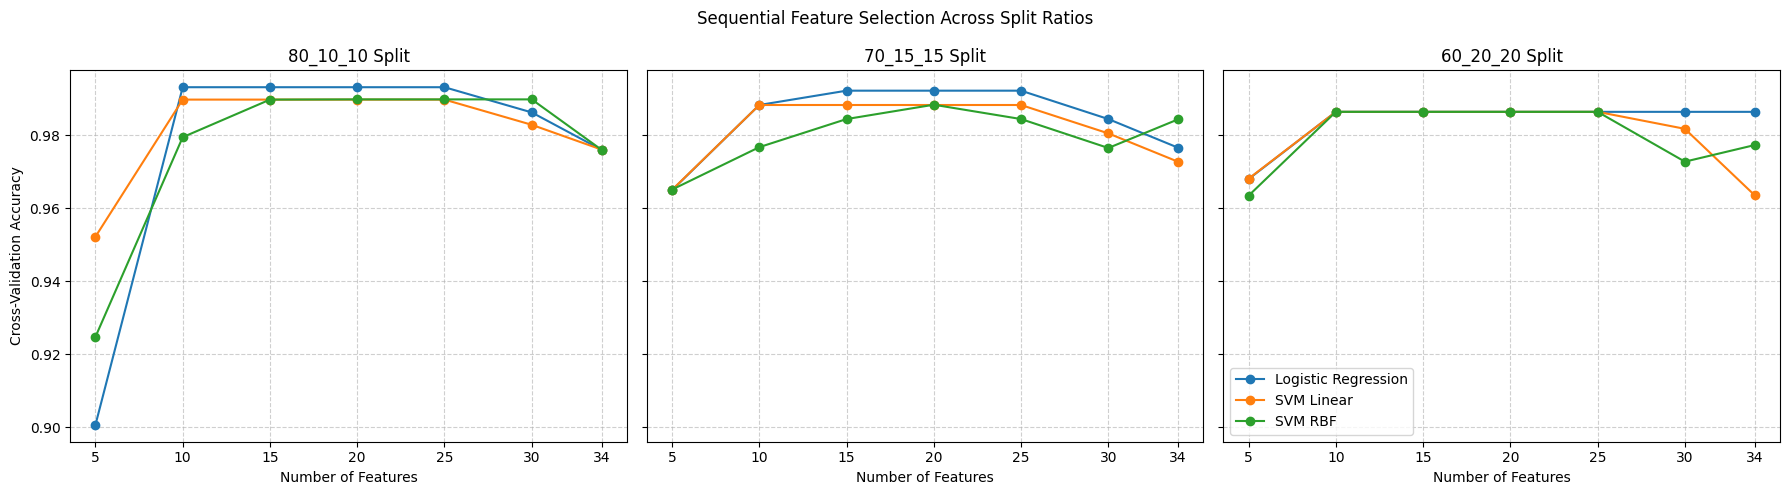

In [24]:
# Create subplots to compare feature count against cross-validation accuracy for each split ratio
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Plot one chart per split ratio
for ax, split_name in zip(axes, sfs_results.keys()):
    # Plot one accuracy curve for each model within the current split ratio
    for model_name, result_df in sfs_results[split_name].items():
        ax.plot(
            result_df['number_of_features'],
            result_df['cv_accuracy'],
            marker='o',
            label=model_name
        )

    # Add title, labels, ticks and grid for the current subplot
    ax.set_title(f'{split_name} Split')
    ax.set_xlabel('Number of Features')
    ax.set_xticks(feature_counts)
    ax.grid(True, linestyle='--', alpha=0.6)

# Add a shared y-axis label and legend
axes[0].set_ylabel('Cross-Validation Accuracy')
axes[-1].legend()

# Add an overall title for all three split-ratio plots
fig.suptitle('Sequential Feature Selection Across Split Ratios')
plt.tight_layout()
plt.show()


In [25]:
# Create dictionaries to store the best SFS result for each split ratio and each model
lr_sfs_optimal_results = {}
svm_linear_sfs_optimal_results = {}
svm_sfs_optimal_results = {}

# Keep the split order consistent with the earlier train/validation/test split section
split_order = ['80_10_10', '70_15_15', '60_20_20']

# Loop through each split ratio to extract the best Logistic Regression, SVM Linear and SVM RBF SFS results
for split_name in split_order:
    # Select the best Logistic Regression row for the current split ratio
    lr_row = sfs_summary_df[
        (sfs_summary_df['split_ratio'] == split_name) &
        (sfs_summary_df['model'] == 'Logistic Regression')
    ].iloc[0]

    # Select the best SVM Linear row for the current split ratio
    svm_linear_row = sfs_summary_df[
        (sfs_summary_df['split_ratio'] == split_name) &
        (sfs_summary_df['model'] == 'SVM Linear')
    ].iloc[0]

    # Select the best SVM RBF row for the current split ratio
    svm_row = sfs_summary_df[
        (sfs_summary_df['split_ratio'] == split_name) &
        (sfs_summary_df['model'] == 'SVM RBF')
    ].iloc[0]

    # Store the optimal Logistic Regression feature selection information for this split
    lr_sfs_optimal_results[split_name] = {
        'optimal_k': int(lr_row['number_of_features']),
        'cv_accuracy': lr_row['cv_accuracy'],
        'cv_std': lr_row['cv_std'],
        'selected_indices': lr_row['selected_indices'],
        'selected_features': lr_row['selected_features']
    }

    # Store the optimal SVM Linear feature selection information for this split
    svm_linear_sfs_optimal_results[split_name] = {
        'optimal_k': int(svm_linear_row['number_of_features']),
        'cv_accuracy': svm_linear_row['cv_accuracy'],
        'cv_std': svm_linear_row['cv_std'],
        'selected_indices': svm_linear_row['selected_indices'],
        'selected_features': svm_linear_row['selected_features']
    }

    # Store the optimal SVM RBF feature selection information for this split
    svm_sfs_optimal_results[split_name] = {
        'optimal_k': int(svm_row['number_of_features']),
        'cv_accuracy': svm_row['cv_accuracy'],
        'cv_std': svm_row['cv_std'],
        'selected_indices': svm_row['selected_indices'],
        'selected_features': svm_row['selected_features']
    }

# Create explicit optimal-k variables for Logistic Regression
lr_optimal_k_80 = lr_sfs_optimal_results['80_10_10']['optimal_k']
lr_optimal_k_70 = lr_sfs_optimal_results['70_15_15']['optimal_k']
lr_optimal_k_60 = lr_sfs_optimal_results['60_20_20']['optimal_k']

# Create explicit selected feature index variables for Logistic Regression
lr_selected_feature_indices_80 = lr_sfs_optimal_results['80_10_10']['selected_indices']
lr_selected_feature_indices_70 = lr_sfs_optimal_results['70_15_15']['selected_indices']
lr_selected_feature_indices_60 = lr_sfs_optimal_results['60_20_20']['selected_indices']

# Create explicit selected feature name variables for Logistic Regression
lr_selected_feature_names_80 = lr_sfs_optimal_results['80_10_10']['selected_features']
lr_selected_feature_names_70 = lr_sfs_optimal_results['70_15_15']['selected_features']
lr_selected_feature_names_60 = lr_sfs_optimal_results['60_20_20']['selected_features']

# Create explicit optimal-k variables for SVM Linear
svm_linear_optimal_k_80 = svm_linear_sfs_optimal_results['80_10_10']['optimal_k']
svm_linear_optimal_k_70 = svm_linear_sfs_optimal_results['70_15_15']['optimal_k']
svm_linear_optimal_k_60 = svm_linear_sfs_optimal_results['60_20_20']['optimal_k']

# Create explicit selected feature index variables for SVM Linear
svm_linear_selected_feature_indices_80 = svm_linear_sfs_optimal_results['80_10_10']['selected_indices']
svm_linear_selected_feature_indices_70 = svm_linear_sfs_optimal_results['70_15_15']['selected_indices']
svm_linear_selected_feature_indices_60 = svm_linear_sfs_optimal_results['60_20_20']['selected_indices']

# Create explicit selected feature name variables for SVM Linear
svm_linear_selected_feature_names_80 = svm_linear_sfs_optimal_results['80_10_10']['selected_features']
svm_linear_selected_feature_names_70 = svm_linear_sfs_optimal_results['70_15_15']['selected_features']
svm_linear_selected_feature_names_60 = svm_linear_sfs_optimal_results['60_20_20']['selected_features']

# Create explicit optimal-k variables for SVM RBF
svm_optimal_k_80 = svm_sfs_optimal_results['80_10_10']['optimal_k']
svm_optimal_k_70 = svm_sfs_optimal_results['70_15_15']['optimal_k']
svm_optimal_k_60 = svm_sfs_optimal_results['60_20_20']['optimal_k']

# Create explicit selected feature index variables for SVM RBF
svm_selected_feature_indices_80 = svm_sfs_optimal_results['80_10_10']['selected_indices']
svm_selected_feature_indices_70 = svm_sfs_optimal_results['70_15_15']['selected_indices']
svm_selected_feature_indices_60 = svm_sfs_optimal_results['60_20_20']['selected_indices']

# Create explicit selected feature name variables for SVM RBF
svm_selected_feature_names_80 = svm_sfs_optimal_results['80_10_10']['selected_features']
svm_selected_feature_names_70 = svm_sfs_optimal_results['70_15_15']['selected_features']
svm_selected_feature_names_60 = svm_sfs_optimal_results['60_20_20']['selected_features']

# Print the optimal number of features and selected features for each split/model combination
for split_name in split_order:
    print(f'Logistic Regression SFS Results for {split_name} split')
    print('Optimal number of features:', lr_sfs_optimal_results[split_name]['optimal_k'])
    print('Selected feature indices:', lr_sfs_optimal_results[split_name]['selected_indices'])
    print('Selected feature names:', lr_sfs_optimal_results[split_name]['selected_features'])
    print('Best 5-fold CV accuracy:', round(lr_sfs_optimal_results[split_name]['cv_accuracy'], 4))
    print('-' * 60)

    print(f'SVM Linear SFS Results for {split_name} split')
    print('Optimal number of features:', svm_linear_sfs_optimal_results[split_name]['optimal_k'])
    print('Selected feature indices:', svm_linear_sfs_optimal_results[split_name]['selected_indices'])
    print('Selected feature names:', svm_linear_sfs_optimal_results[split_name]['selected_features'])
    print('Best 5-fold CV accuracy:', round(svm_linear_sfs_optimal_results[split_name]['cv_accuracy'], 4))
    print('-' * 60)

    print(f'SVM RBF SFS Results for {split_name} split')
    print('Optimal number of features:', svm_sfs_optimal_results[split_name]['optimal_k'])
    print('Selected feature indices:', svm_sfs_optimal_results[split_name]['selected_indices'])
    print('Selected feature names:', svm_sfs_optimal_results[split_name]['selected_features'])
    print('Best 5-fold CV accuracy:', round(svm_sfs_optimal_results[split_name]['cv_accuracy'], 4))
    print('=' * 60)


Logistic Regression SFS Results for 80_10_10 split
Optimal number of features: 10
Selected feature indices: [4, 6, 8, 13, 14, 17, 20, 25, 26, 27]
Selected feature names: ['koebner_phenomenon', 'follicular_papules', 'knee_and_elbow_involvement', 'PNL_infiltrate', 'fibrosis_of_the_papillary_dermis', 'hyperkeratosis', 'elongation_of_the_rete_ridges', 'disappearance_of_the_granular_layer', 'vacuolisation_and_damage_of_basal_layer', 'spongiosis']
Best 5-fold CV accuracy: 0.9931
------------------------------------------------------------
SVM Linear SFS Results for 80_10_10 split
Optimal number of features: 10
Selected feature indices: [1, 4, 14, 19, 20, 21, 25, 26, 29, 30]
Selected feature names: ['scaling', 'koebner_phenomenon', 'fibrosis_of_the_papillary_dermis', 'clubbing_of_the_rete_ridges', 'elongation_of_the_rete_ridges', 'thinning_of_the_suprapapillary_epidermis', 'disappearance_of_the_granular_layer', 'vacuolisation_and_damage_of_basal_layer', 'follicular_horn_plug', 'perifollicular

In [26]:
# Create Logistic Regression SFS datasets for the 80/10/10 split
lr_x_train_80_sfs = lr_x_train_80.iloc[:, lr_selected_feature_indices_80]
lr_x_val_10_sfs = lr_x_val_10.iloc[:, lr_selected_feature_indices_80]
lr_x_test_10_sfs = lr_x_test_10.iloc[:, lr_selected_feature_indices_80]

# Create Logistic Regression SFS datasets for the 70/15/15 split
lr_x_train_70_sfs = lr_x_train_70.iloc[:, lr_selected_feature_indices_70]
lr_x_val_15_sfs = lr_x_val_15.iloc[:, lr_selected_feature_indices_70]
lr_x_test_15_sfs = lr_x_test_15.iloc[:, lr_selected_feature_indices_70]

# Create Logistic Regression SFS datasets for the 60/20/20 split
lr_x_train_60_sfs = lr_x_train_60.iloc[:, lr_selected_feature_indices_60]
lr_x_val_20_sfs = lr_x_val_20.iloc[:, lr_selected_feature_indices_60]
lr_x_test_20_sfs = lr_x_test_20.iloc[:, lr_selected_feature_indices_60]

# Create SVM Linear SFS datasets for the 80/10/10 split
svm_linear_x_train_80_sfs = svm_x_train_80.iloc[:, svm_linear_selected_feature_indices_80]
svm_linear_x_val_10_sfs = svm_x_val_10.iloc[:, svm_linear_selected_feature_indices_80]
svm_linear_x_test_10_sfs = svm_x_test_10.iloc[:, svm_linear_selected_feature_indices_80]

# Create SVM Linear SFS datasets for the 70/15/15 split
svm_linear_x_train_70_sfs = svm_x_train_70.iloc[:, svm_linear_selected_feature_indices_70]
svm_linear_x_val_15_sfs = svm_x_val_15.iloc[:, svm_linear_selected_feature_indices_70]
svm_linear_x_test_15_sfs = svm_x_test_15.iloc[:, svm_linear_selected_feature_indices_70]

# Create SVM Linear SFS datasets for the 60/20/20 split
svm_linear_x_train_60_sfs = svm_x_train_60.iloc[:, svm_linear_selected_feature_indices_60]
svm_linear_x_val_20_sfs = svm_x_val_20.iloc[:, svm_linear_selected_feature_indices_60]
svm_linear_x_test_20_sfs = svm_x_test_20.iloc[:, svm_linear_selected_feature_indices_60]

# Create SVM RBF SFS datasets for the 80/10/10 split
svm_x_train_80_sfs = svm_x_train_80.iloc[:, svm_selected_feature_indices_80]
svm_x_val_10_sfs = svm_x_val_10.iloc[:, svm_selected_feature_indices_80]
svm_x_test_10_sfs = svm_x_test_10.iloc[:, svm_selected_feature_indices_80]

# Create SVM RBF SFS datasets for the 70/15/15 split
svm_x_train_70_sfs = svm_x_train_70.iloc[:, svm_selected_feature_indices_70]
svm_x_val_15_sfs = svm_x_val_15.iloc[:, svm_selected_feature_indices_70]
svm_x_test_15_sfs = svm_x_test_15.iloc[:, svm_selected_feature_indices_70]

# Create SVM RBF SFS datasets for the 60/20/20 split
svm_x_train_60_sfs = svm_x_train_60.iloc[:, svm_selected_feature_indices_60]
svm_x_val_20_sfs = svm_x_val_20.iloc[:, svm_selected_feature_indices_60]
svm_x_test_20_sfs = svm_x_test_20.iloc[:, svm_selected_feature_indices_60]

# Store the three Logistic Regression SFS-ready datasets in one dictionary for model training
logistic_regression_sfs_datasets = {
    '80_10_10': {
        'X_train': lr_x_train_80_sfs,
        'X_val': lr_x_val_10_sfs,
        'X_test': lr_x_test_10_sfs,
        'y_train': lr_y_train_80,
        'y_val': lr_y_val_10,
        'y_test': lr_y_test_10,
        'optimal_k': lr_optimal_k_80,
        'selected_indices': lr_selected_feature_indices_80,
        'selected_features': lr_selected_feature_names_80
    },
    '70_15_15': {
        'X_train': lr_x_train_70_sfs,
        'X_val': lr_x_val_15_sfs,
        'X_test': lr_x_test_15_sfs,
        'y_train': lr_y_train_70,
        'y_val': lr_y_val_15,
        'y_test': lr_y_test_15,
        'optimal_k': lr_optimal_k_70,
        'selected_indices': lr_selected_feature_indices_70,
        'selected_features': lr_selected_feature_names_70
    },
    '60_20_20': {
        'X_train': lr_x_train_60_sfs,
        'X_val': lr_x_val_20_sfs,
        'X_test': lr_x_test_20_sfs,
        'y_train': lr_y_train_60,
        'y_val': lr_y_val_20,
        'y_test': lr_y_test_20,
        'optimal_k': lr_optimal_k_60,
        'selected_indices': lr_selected_feature_indices_60,
        'selected_features': lr_selected_feature_names_60
    }
}

# Store the three SVM Linear SFS-ready datasets in one dictionary for model training
svm_linear_sfs_datasets = {
    '80_10_10': {
        'X_train': svm_linear_x_train_80_sfs,
        'X_val': svm_linear_x_val_10_sfs,
        'X_test': svm_linear_x_test_10_sfs,
        'y_train': svm_y_train_80,
        'y_val': svm_y_val_10,
        'y_test': svm_y_test_10,
        'optimal_k': svm_linear_optimal_k_80,
        'selected_indices': svm_linear_selected_feature_indices_80,
        'selected_features': svm_linear_selected_feature_names_80
    },
    '70_15_15': {
        'X_train': svm_linear_x_train_70_sfs,
        'X_val': svm_linear_x_val_15_sfs,
        'X_test': svm_linear_x_test_15_sfs,
        'y_train': svm_y_train_70,
        'y_val': svm_y_val_15,
        'y_test': svm_y_test_15,
        'optimal_k': svm_linear_optimal_k_70,
        'selected_indices': svm_linear_selected_feature_indices_70,
        'selected_features': svm_linear_selected_feature_names_70
    },
    '60_20_20': {
        'X_train': svm_linear_x_train_60_sfs,
        'X_val': svm_linear_x_val_20_sfs,
        'X_test': svm_linear_x_test_20_sfs,
        'y_train': svm_y_train_60,
        'y_val': svm_y_val_20,
        'y_test': svm_y_test_20,
        'optimal_k': svm_linear_optimal_k_60,
        'selected_indices': svm_linear_selected_feature_indices_60,
        'selected_features': svm_linear_selected_feature_names_60
    }
}

# Store the three SVM RBF SFS-ready datasets in one dictionary for model training
svm_sfs_datasets = {
    '80_10_10': {
        'X_train': svm_x_train_80_sfs,
        'X_val': svm_x_val_10_sfs,
        'X_test': svm_x_test_10_sfs,
        'y_train': svm_y_train_80,
        'y_val': svm_y_val_10,
        'y_test': svm_y_test_10,
        'optimal_k': svm_optimal_k_80,
        'selected_indices': svm_selected_feature_indices_80,
        'selected_features': svm_selected_feature_names_80
    },
    '70_15_15': {
        'X_train': svm_x_train_70_sfs,
        'X_val': svm_x_val_15_sfs,
        'X_test': svm_x_test_15_sfs,
        'y_train': svm_y_train_70,
        'y_val': svm_y_val_15,
        'y_test': svm_y_test_15,
        'optimal_k': svm_optimal_k_70,
        'selected_indices': svm_selected_feature_indices_70,
        'selected_features': svm_selected_feature_names_70
    },
    '60_20_20': {
        'X_train': svm_x_train_60_sfs,
        'X_val': svm_x_val_20_sfs,
        'X_test': svm_x_test_20_sfs,
        'y_train': svm_y_train_60,
        'y_val': svm_y_val_20,
        'y_test': svm_y_test_20,
        'optimal_k': svm_optimal_k_60,
        'selected_indices': svm_selected_feature_indices_60,
        'selected_features': svm_selected_feature_names_60
    }
}

# Display the final dataset shapes for all nine SFS-ready datasets
for split_name in split_order:
    print(f'Logistic Regression {split_name} SFS shapes:')
    print(logistic_regression_sfs_datasets[split_name]['X_train'].shape,
          logistic_regression_sfs_datasets[split_name]['X_val'].shape,
          logistic_regression_sfs_datasets[split_name]['X_test'].shape)

    print(f'SVM Linear {split_name} SFS shapes:')
    print(svm_linear_sfs_datasets[split_name]['X_train'].shape,
          svm_linear_sfs_datasets[split_name]['X_val'].shape,
          svm_linear_sfs_datasets[split_name]['X_test'].shape)

    print(f'SVM RBF {split_name} SFS shapes:')
    print(svm_sfs_datasets[split_name]['X_train'].shape,
          svm_sfs_datasets[split_name]['X_val'].shape,
          svm_sfs_datasets[split_name]['X_test'].shape)
    print('-' * 60)


Logistic Regression 80_10_10 SFS shapes:
(292, 10) (37, 10) (37, 10)
SVM Linear 80_10_10 SFS shapes:
(292, 10) (37, 10) (37, 10)
SVM RBF 80_10_10 SFS shapes:
(292, 20) (37, 20) (37, 20)
------------------------------------------------------------
Logistic Regression 70_15_15 SFS shapes:
(256, 15) (55, 15) (55, 15)
SVM Linear 70_15_15 SFS shapes:
(256, 10) (55, 10) (55, 10)
SVM RBF 70_15_15 SFS shapes:
(256, 20) (55, 20) (55, 20)
------------------------------------------------------------
Logistic Regression 60_20_20 SFS shapes:
(219, 10) (73, 10) (74, 10)
SVM Linear 60_20_20 SFS shapes:
(219, 10) (73, 10) (74, 10)
SVM RBF 60_20_20 SFS shapes:
(219, 10) (73, 10) (74, 10)
------------------------------------------------------------


# Preprocessing Summary
- The CSV file was loaded without headers using column names from the dermatology README.
- The `?` missing marker was converted into `NaN`.
- Missing `age` values were imputed using the median age.
- Duplicate rows were checked.
- IQR-based row removal was not applied because most features are valid ordinal medical scores from 0 to 3.
- The final class distribution table and plot were placed after outlier checking.
- Stratified 80/10/10, 70/15/15, and 60/20/20 train/validation/test splits were prepared.
- Standardization was fitted on the training set only for each split ratio and applied to validation and test sets.
- Scaled datasets were prepared for Logistic Regression and SVM.
- Forward Sequential Feature Selection [1], [2] was applied for Logistic Regression, SVM Linear and SVM RBF across all three split ratios using `SequentialFeatureSelector` from scikit-learn [3].
- Candidate feature counts `[5, 10, 15, 20, 25, 30, 34]` were evaluated first using 5-fold cross-validation accuracy to reduce runtime.
- The optimal number of features, selected feature indices, and selected feature names were stored separately for each split ratio and each model.
- Nine model-ready SFS datasets were prepared: three for Logistic Regression, three for SVM Linear and three for SVM RBF.


# Data modeling
Build the machine learning models. You must build atleast two (2) predictive models. One of the predictive models must be either Decision Tree or Support Vector Machine.
________________________________________________________________________________
Description: Three predictive models are constructed: Logistic Regression, SVM Linear and SVM RBF. Each model is trained and fine-tuned with `GridSearchCV` across all three split ratios (80/10/10, 70/15/15, 60/20/20) using its own SFS-selected feature subsets [1], [2]. The best model configuration for each algorithm is selected using validation weighted F1-score.


## Logistic Regression


### Hyperparameter Fine-Tuning (GridSearchCV)


In [27]:
print('--- Starting Logistic Regression Hyperparameter Tuning on SFS Features ---')

# Fine-tuning grid for Logistic Regression.
# C controls regularization strength, solver controls optimization, and class_weight helps with imbalance.
logistic_regression_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

# Containers for tuned models and comparison rows.
lr_tuned_models = {}
logistic_regression_tuning_rows = []
best_lr_score = -1
best_lr_split = None
best_lr_model = None
best_lr_test_data = None
best_lr_params = None
best_lr_selected_features = None

# Loop through the SFS-ready datasets created in the feature-selection section.
for split_name, split_data in logistic_regression_sfs_datasets.items():
    print()
    print(f'Fine-tuning Logistic Regression for {split_name} split')

    X_train_opt = split_data['X_train']
    y_train_opt = split_data['y_train']
    X_val_opt = split_data['X_val']
    y_val_opt = split_data['y_val']

    grid_search = GridSearchCV(
        estimator=LogisticRegression(max_iter=1000, random_state=42),
        param_grid=logistic_regression_param_grid,
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1,
        return_train_score=True
    )

    # Fit the grid search only on the training set to avoid validation/test leakage.
    grid_search.fit(X_train_opt, y_train_opt)
    best_model_for_split = grid_search.best_estimator_
    val_predictions = best_model_for_split.predict(X_val_opt)

    # Store validation metrics for model selection and reporting.
    val_accuracy = accuracy_score(y_val_opt, val_predictions)
    val_precision_weighted = precision_score(y_val_opt, val_predictions, average='weighted', zero_division=0)
    val_recall_weighted = recall_score(y_val_opt, val_predictions, average='weighted', zero_division=0)
    val_f1_weighted = f1_score(y_val_opt, val_predictions, average='weighted', zero_division=0)

    lr_tuned_models[split_name] = best_model_for_split
    logistic_regression_tuning_rows.append({
        'split_ratio': split_name,
        'optimal_k': split_data['optimal_k'],
        'selected_features': split_data['selected_features'],
        'best_params': grid_search.best_params_,
        'cv_f1_weighted': grid_search.best_score_,
        'validation_accuracy': val_accuracy,
        'validation_precision_weighted': val_precision_weighted,
        'validation_recall_weighted': val_recall_weighted,
        'validation_f1_weighted': val_f1_weighted
    })

    print('Best parameters:', grid_search.best_params_)
    print('Cross-validation weighted F1:', round(grid_search.best_score_, 4))
    print('Validation weighted F1:', round(val_f1_weighted, 4))

    # Select the final Logistic Regression model using validation weighted F1-score.
    if val_f1_weighted > best_lr_score:
        best_lr_score = val_f1_weighted
        best_lr_split = split_name
        best_lr_model = best_model_for_split
        best_lr_test_data = (split_data['X_test'], split_data['y_test'])
        best_lr_params = grid_search.best_params_
        best_lr_selected_features = split_data['selected_features']

# Display a clear tuning summary for all split ratios.
logistic_regression_tuning_summary = pd.DataFrame(logistic_regression_tuning_rows)
metric_columns = [
    'cv_f1_weighted',
    'validation_accuracy',
    'validation_precision_weighted',
    'validation_recall_weighted',
    'validation_f1_weighted'
]
logistic_regression_tuning_summary[metric_columns] = logistic_regression_tuning_summary[metric_columns].round(4)

print()
print(f'Best Logistic Regression split: {best_lr_split}')
print('Best Logistic Regression validation weighted F1:', round(best_lr_score, 4))
print('Best Logistic Regression parameters:', best_lr_params)
print('Selected features used by final Logistic Regression model:', best_lr_selected_features)

logistic_regression_tuning_summary


--- Starting Logistic Regression Hyperparameter Tuning on SFS Features ---

Fine-tuning Logistic Regression for 80_10_10 split
Best parameters: {'C': 1, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Cross-validation weighted F1: 0.9896
Validation weighted F1: 0.9723

Fine-tuning Logistic Regression for 70_15_15 split
Best parameters: {'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Cross-validation weighted F1: 0.992
Validation weighted F1: 0.8886

Fine-tuning Logistic Regression for 60_20_20 split
Best parameters: {'C': 1, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Cross-validation weighted F1: 0.9765
Validation weighted F1: 0.8918

Best Logistic Regression split: 80_10_10
Best Logistic Regression validation weighted F1: 0.9723
Best Logistic Regression parameters: {'C': 1, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Selected features used by final Logistic Regression model: ['koebner_phenomenon', 'follicular_papules', 'knee_a

,split_ratio,optimal_k,selected_features,best_params,cv_f1_weighted,validation_accuracy,validation_precision_weighted,validation_recall_weighted,validation_f1_weighted
0,80_10_10,10,"[koebner_phenomenon, follicular_papules, knee_...","{'C': 1, 'class_weight': None, 'penalty': 'l2'...",0.9896,0.9730,0.9752,0.9730,0.9723
1,70_15_15,15,"[koebner_phenomenon, follicular_papules, knee_...","{'C': 10, 'class_weight': None, 'penalty': 'l2...",0.9920,0.8909,0.8984,0.8909,0.8886
2,60_20_20,10,"[scaling, definite_borders, koebner_phenomenon...","{'C': 1, 'class_weight': None, 'penalty': 'l2'...",0.9765,0.8904,0.8960,0.8904,0.8918


### Final Evaluation on Unseen Test Set
**Description:** The best Logistic Regression model selected from validation performance is evaluated once on its corresponding unseen test set. Accuracy, precision, recall, F1-score and a detailed classification report are reported for the multi-class classification task.


In [28]:
# Retrieve the prepared test set that matches the best Logistic Regression split.
lr_X_test_final, lr_y_test_final = best_lr_test_data

# Generate predictions using the final tuned Logistic Regression model.
lr_test_predictions = best_lr_model.predict(lr_X_test_final)

# Define class labels and readable class names for consistent reports.
lr_class_labels = sorted(lr_y_test_final.unique())
lr_target_names = [class_names[label] for label in lr_class_labels]

# Calculate the required classification metrics.
logistic_regression_test_metrics = {
    'model': 'Logistic Regression',
    'dataset': 'Test',
    'split_ratio': best_lr_split,
    'accuracy': accuracy_score(lr_y_test_final, lr_test_predictions),
    'precision_weighted': precision_score(lr_y_test_final, lr_test_predictions, average='weighted', zero_division=0),
    'recall_weighted': recall_score(lr_y_test_final, lr_test_predictions, average='weighted', zero_division=0),
    'f1_weighted': f1_score(lr_y_test_final, lr_test_predictions, average='weighted', zero_division=0),
    'precision_macro': precision_score(lr_y_test_final, lr_test_predictions, average='macro', zero_division=0),
    'recall_macro': recall_score(lr_y_test_final, lr_test_predictions, average='macro', zero_division=0),
    'f1_macro': f1_score(lr_y_test_final, lr_test_predictions, average='macro', zero_division=0)
}

print('=== Final Logistic Regression Evaluation ===')
print(f'Evaluating the best Logistic Regression model from the {best_lr_split} split on the unseen test set.')
print()
print('--- Core Performance Metrics ---')
print(f"Accuracy  : {logistic_regression_test_metrics['accuracy']:.4f}")
print(f"Precision : {logistic_regression_test_metrics['precision_weighted']:.4f} (Weighted Average)")
print(f"Recall    : {logistic_regression_test_metrics['recall_weighted']:.4f} (Weighted Average)")
print(f"F1-Score  : {logistic_regression_test_metrics['f1_weighted']:.4f} (Weighted Average)")
print()

print('--- Detailed Classification Report ---')
print(classification_report(
    lr_y_test_final,
    lr_test_predictions,
    labels=lr_class_labels,
    target_names=lr_target_names,
    zero_division=0
))


=== Final Logistic Regression Evaluation ===
Evaluating the best Logistic Regression model from the 80_10_10 split on the unseen test set.

--- Core Performance Metrics ---
Accuracy  : 0.8919
Precision : 0.8976 (Weighted Average)
Recall    : 0.8919 (Weighted Average)
F1-Score  : 0.8914 (Weighted Average)

--- Detailed Classification Report ---
                          precision    recall  f1-score   support

               psoriasis       0.92      1.00      0.96        12
     seboreic dermatitis       0.80      0.67      0.73         6
           lichen planus       1.00      0.86      0.92         7
        pityriasis rosea       0.67      0.80      0.73         5
       cronic dermatitis       1.00      1.00      1.00         5
pityriasis rubra pilaris       1.00      1.00      1.00         2

                accuracy                           0.89        37
               macro avg       0.90      0.89      0.89        37
            weighted avg       0.90      0.89      0.89   

### Confusion Matrix
**Description:** The confusion matrix visualises which specific skin diseases the Logistic Regression model is classifying correctly, and which ones it is confusing with each other.


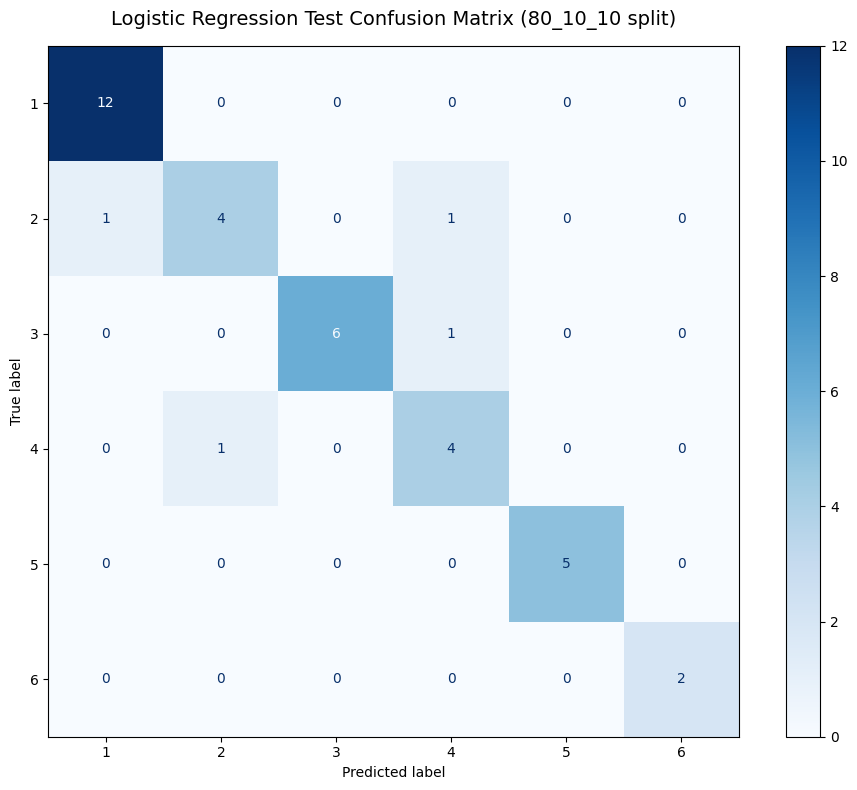

In [29]:
# Calculate and display the Logistic Regression confusion matrix.
lr_cm = confusion_matrix(
    lr_y_test_final,
    lr_test_predictions,
    labels=lr_class_labels
)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(
    confusion_matrix=lr_cm,
    display_labels=lr_class_labels
).plot(
    cmap='Blues',
    ax=ax,
    values_format='d'
)

plt.title(f'Logistic Regression Test Confusion Matrix ({best_lr_split} split)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


### Results and Discussion: Logistic Regression
**Description:** Analysis of the Logistic Regression model's performance, hyperparameter selection, and handling of the imbalanced dermatology dataset.


#### Logistic Regression Discussion

The Logistic Regression model uses the SFS-selected feature subsets created earlier in the notebook. All three train/validation/test split ratios are fine-tuned with `GridSearchCV`, and the final Logistic Regression candidate is selected using validation weighted F1-score. The unseen test set is not used during tuning or model selection; it is used only once to estimate the final generalisation performance of the selected Logistic Regression model.

On the unseen test set, Logistic Regression achieves **0.8919 accuracy**, **0.8976 weighted precision**, **0.8919 weighted recall**, and **0.8914 weighted F1-score**. Its weighted F1-score is slightly higher than the final SVM model, so Logistic Regression has the best reported test performance in Part 1. The model performs especially well for classes 1, 5 and 6, while the lower scores for classes 2 and 4 show that these disease categories are more difficult to separate.

The confusion matrix supports this interpretation: most predictions fall on the diagonal, but the main errors occur around the visually/clinically similar classes with lower support. Regression metrics such as R2 score, mean squared error and mean absolute error are not reported because the target variable is a disease class label rather than a continuous numeric value.

## SVM Predictive Model Training and Fine-Tuning

The Dermatology dataset is a **multi-class classification** problem because the target variable `class` represents six disease categories. Therefore, the required classification metrics are reported: accuracy, precision, recall, F1-score and confusion matrix.

Regression metrics such as R2 score, mean squared error and mean absolute error are **not applicable** for this dataset because the target values are class labels, not continuous numerical values.


### Hyperparameter Fine-Tuning (GridSearchCV)

Two SVM kernel types are trained and fine-tuned across all three split ratios (80/10/10, 70/15/15, 60/20/20):

1. **Linear SVM**: uses SVM Linear SFS-selected features for each split ratio.
2. **RBF SVM**: uses SVM RBF SFS-selected features for each split ratio.

`GridSearchCV` is used on the training set only. The validation set is kept separate for model comparison after tuning, and the test set is used only for final evaluation.


In [30]:
print('--- Starting SVM Hyperparameter Tuning on SFS Features ---')

# Define a stratified cross-validation strategy so each fold keeps similar class proportions.
svm_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Fine-tuning grid for Linear SVM.
linear_svm_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced']
}

# Fine-tuning grid for RBF SVM.
rbf_svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'class_weight': [None, 'balanced']
}

# Containers for tuned models and comparison rows.
svm_tuned_models = {}
svm_tuning_rows = []

# Define the SVM kernel configurations with their matching SFS datasets.
svm_configs = {
    'SVM Linear': {
        'base_estimator': SVC(kernel='linear', random_state=42),
        'param_grid': linear_svm_param_grid,
        'sfs_datasets': svm_linear_sfs_datasets
    },
    'SVM RBF': {
        'base_estimator': SVC(kernel='rbf', random_state=42),
        'param_grid': rbf_svm_param_grid,
        'sfs_datasets': svm_sfs_datasets
    }
}

# Loop through each SVM kernel type and each split ratio.
for svm_name, svm_config in svm_configs.items():
    for split_name, split_data in svm_config['sfs_datasets'].items():
        print()
        print(f'Fine-tuning {svm_name} for {split_name} split')

        X_train_opt = split_data['X_train']
        y_train_opt = split_data['y_train']
        X_val_opt = split_data['X_val']
        y_val_opt = split_data['y_val']

        grid_search = GridSearchCV(
            estimator=copy.deepcopy(svm_config['base_estimator']),
            param_grid=svm_config['param_grid'],
            scoring='f1_weighted',
            cv=svm_cv,
            n_jobs=-1,
            return_train_score=True
        )

        # Fit the grid search only on the training set.
        grid_search.fit(X_train_opt, y_train_opt)
        best_model_for_split = grid_search.best_estimator_
        val_predictions = best_model_for_split.predict(X_val_opt)

        # Store validation metrics for model selection and reporting.
        val_accuracy = accuracy_score(y_val_opt, val_predictions)
        val_precision_weighted = precision_score(y_val_opt, val_predictions, average='weighted', zero_division=0)
        val_recall_weighted = recall_score(y_val_opt, val_predictions, average='weighted', zero_division=0)
        val_f1_weighted = f1_score(y_val_opt, val_predictions, average='weighted', zero_division=0)

        model_key = f'{svm_name}_{split_name}'
        svm_tuned_models[model_key] = {
            'model': best_model_for_split,
            'svm_name': svm_name,
            'split_name': split_name,
            'test_data': (split_data['X_test'], split_data['y_test']),
            'selected_features': split_data['selected_features']
        }
        svm_tuning_rows.append({
            'model': svm_name,
            'split_ratio': split_name,
            'optimal_k': split_data['optimal_k'],
            'selected_features': split_data['selected_features'],
            'best_params': grid_search.best_params_,
            'cv_f1_weighted': grid_search.best_score_,
            'validation_accuracy': val_accuracy,
            'validation_precision_weighted': val_precision_weighted,
            'validation_recall_weighted': val_recall_weighted,
            'validation_f1_weighted': val_f1_weighted
        })

        print('Best parameters:', grid_search.best_params_)
        print('Cross-validation weighted F1:', round(grid_search.best_score_, 4))
        print('Validation weighted F1:', round(val_f1_weighted, 4))

# Display a clear tuning summary for all SVM kernel and split combinations.
svm_tuning_summary = pd.DataFrame(svm_tuning_rows)
svm_metric_columns = [
    'cv_f1_weighted',
    'validation_accuracy',
    'validation_precision_weighted',
    'validation_recall_weighted',
    'validation_f1_weighted'
]
svm_tuning_summary[svm_metric_columns] = svm_tuning_summary[svm_metric_columns].round(4)

# Select the single best SVM model (kernel + split) using validation weighted F1-score.
best_svm_row = svm_tuning_summary.loc[svm_tuning_summary['validation_f1_weighted'].idxmax()]
best_svm_key = f"{best_svm_row['model']}_{best_svm_row['split_ratio']}"
best_svm_info = svm_tuned_models[best_svm_key]
best_svm_model = best_svm_info['model']
best_svm_model_name = best_svm_info['svm_name']
best_svm_split = best_svm_info['split_name']
best_svm_test_data = best_svm_info['test_data']
best_svm_selected_features = best_svm_info['selected_features']

print()
print(f'Best SVM model: {best_svm_model_name} from {best_svm_split} split')
print('Best SVM validation weighted F1:', round(best_svm_row['validation_f1_weighted'], 4))
print('Best SVM parameters:', best_svm_row['best_params'])
print('Selected features used by final SVM model:', best_svm_selected_features)

svm_tuning_summary


--- Starting SVM Hyperparameter Tuning on SFS Features ---

Fine-tuning SVM Linear for 80_10_10 split
Best parameters: {'C': 1, 'class_weight': None}
Cross-validation weighted F1: 0.9895
Validation weighted F1: 1.0

Fine-tuning SVM Linear for 70_15_15 split
Best parameters: {'C': 1, 'class_weight': None}
Cross-validation weighted F1: 0.9879
Validation weighted F1: 0.9241

Fine-tuning SVM Linear for 60_20_20 split
Best parameters: {'C': 1, 'class_weight': None}
Cross-validation weighted F1: 0.9861
Validation weighted F1: 0.9322

Fine-tuning SVM RBF for 80_10_10 split
Best parameters: {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale'}
Cross-validation weighted F1: 0.9932
Validation weighted F1: 1.0

Fine-tuning SVM RBF for 70_15_15 split
Best parameters: {'C': 1, 'class_weight': None, 'gamma': 'scale'}
Cross-validation weighted F1: 0.9882
Validation weighted F1: 0.9816

Fine-tuning SVM RBF for 60_20_20 split
Best parameters: {'C': 1, 'class_weight': None, 'gamma': 'scale'}
Cross-vali

,model,split_ratio,optimal_k,selected_features,best_params,cv_f1_weighted,validation_accuracy,validation_precision_weighted,validation_recall_weighted,validation_f1_weighted
0,SVM Linear,80_10_10,10,"[scaling, koebner_phenomenon, fibrosis_of_the_...","{'C': 1, 'class_weight': None}",0.9895,1.0000,1.0000,1.0000,1.0000
1,SVM Linear,70_15_15,10,"[erythema, koebner_phenomenon, family_history,...","{'C': 1, 'class_weight': None}",0.9879,0.9273,0.9375,0.9273,0.9241
2,SVM Linear,60_20_20,10,"[erythema, koebner_phenomenon, follicular_papu...","{'C': 1, 'class_weight': None}",0.9861,0.9315,0.9393,0.9315,0.9322
3,SVM RBF,80_10_10,20,"[erythema, scaling, definite_borders, itching,...","{'C': 1, 'class_weight': 'balanced', 'gamma': ...",0.9932,1.0000,1.0000,1.0000,1.0000
4,SVM RBF,70_15_15,20,"[erythema, koebner_phenomenon, polygonal_papul...","{'C': 1, 'class_weight': None, 'gamma': 'scale'}",0.9882,0.9818,0.9836,0.9818,0.9816
5,SVM RBF,60_20_20,10,"[scaling, definite_borders, koebner_phenomenon...","{'C': 1, 'class_weight': None, 'gamma': 'scale'}",0.9861,0.9041,0.9079,0.9041,0.9046


### Final Evaluation on Unseen Test Set
**Description:** The best SVM model selected from validation performance is evaluated once on its corresponding unseen test set. Accuracy, precision, recall, F1-score and a detailed classification report are reported for the multi-class classification task.


In [31]:
# Retrieve the prepared test set that matches the best SVM split.
svm_X_test_final, svm_y_test_final = best_svm_test_data

# Generate predictions using the final tuned SVM model.
svm_test_predictions = best_svm_model.predict(svm_X_test_final)

# Define class labels and readable class names for consistent reports.
svm_class_labels = sorted(svm_y_test_final.unique())
svm_target_names = [class_names[label] for label in svm_class_labels]

# Calculate the required classification metrics.
svm_test_metrics = {
    'model': best_svm_model_name,
    'dataset': 'Test',
    'split_ratio': best_svm_split,
    'accuracy': accuracy_score(svm_y_test_final, svm_test_predictions),
    'precision_weighted': precision_score(svm_y_test_final, svm_test_predictions, average='weighted', zero_division=0),
    'recall_weighted': recall_score(svm_y_test_final, svm_test_predictions, average='weighted', zero_division=0),
    'f1_weighted': f1_score(svm_y_test_final, svm_test_predictions, average='weighted', zero_division=0),
    'precision_macro': precision_score(svm_y_test_final, svm_test_predictions, average='macro', zero_division=0),
    'recall_macro': recall_score(svm_y_test_final, svm_test_predictions, average='macro', zero_division=0),
    'f1_macro': f1_score(svm_y_test_final, svm_test_predictions, average='macro', zero_division=0)
}

print(f'=== Final {best_svm_model_name} Evaluation ===')
print(f'Evaluating the best SVM model ({best_svm_model_name}) from the {best_svm_split} split on the unseen test set.')
print()
print('--- Core Performance Metrics ---')
print(f"Accuracy  : {svm_test_metrics['accuracy']:.4f}")
print(f"Precision : {svm_test_metrics['precision_weighted']:.4f} (Weighted Average)")
print(f"Recall    : {svm_test_metrics['recall_weighted']:.4f} (Weighted Average)")
print(f"F1-Score  : {svm_test_metrics['f1_weighted']:.4f} (Weighted Average)")
print()

print('--- Detailed Classification Report ---')
print(classification_report(
    svm_y_test_final,
    svm_test_predictions,
    labels=svm_class_labels,
    target_names=svm_target_names,
    zero_division=0
))


=== Final SVM Linear Evaluation ===
Evaluating the best SVM model (SVM Linear) from the 80_10_10 split on the unseen test set.

--- Core Performance Metrics ---
Accuracy  : 0.8919
Precision : 0.8955 (Weighted Average)
Recall    : 0.8919 (Weighted Average)
F1-Score  : 0.8896 (Weighted Average)

--- Detailed Classification Report ---
                          precision    recall  f1-score   support

               psoriasis       1.00      1.00      1.00        12
     seboreic dermatitis       0.80      0.67      0.73         6
           lichen planus       1.00      0.86      0.92         7
        pityriasis rosea       0.83      1.00      0.91         5
       cronic dermatitis       0.83      1.00      0.91         5
pityriasis rubra pilaris       0.50      0.50      0.50         2

                accuracy                           0.89        37
               macro avg       0.83      0.84      0.83        37
            weighted avg       0.90      0.89      0.89        37



### Confusion Matrix
**Description:** The confusion matrix visualises which specific skin diseases the SVM model is classifying correctly, and which ones it is confusing with each other.


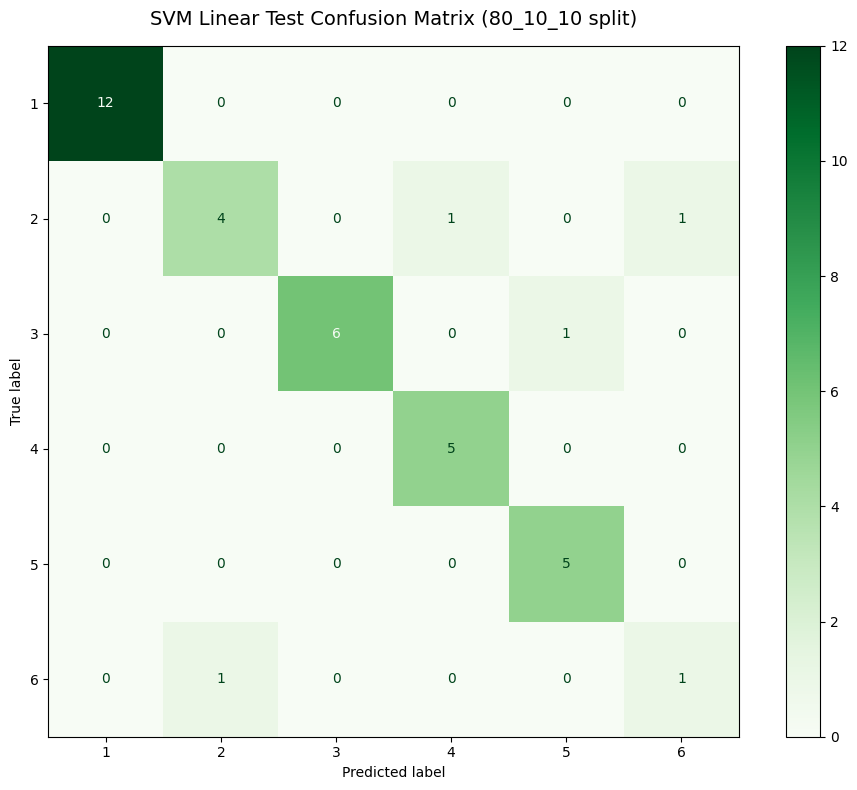

In [32]:
# Calculate and display the SVM confusion matrix.
svm_cm = confusion_matrix(
    svm_y_test_final,
    svm_test_predictions,
    labels=svm_class_labels
)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(
    confusion_matrix=svm_cm,
    display_labels=svm_class_labels
).plot(
    cmap='Greens',
    ax=ax,
    values_format='d'
)

plt.title(f'{best_svm_model_name} Test Confusion Matrix ({best_svm_split} split)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


### Results and Discussion: SVM
**Description:** Analysis of the SVM model's performance, hyperparameter selection, and handling of the imbalanced dermatology dataset.


#### SVM Discussion

The SVM section trains and fine-tunes both Linear SVM and RBF SVM candidates using the SFS-selected feature subsets. Both SVM models are evaluated across the 80/10/10, 70/15/15 and 60/20/20 split ratios with stratified 5-fold `GridSearchCV`, and the final SVM candidate is selected using validation weighted F1-score.

The best SVM candidate is **SVM Linear** from the **80/10/10** split. On the unseen test set, it achieves **0.8919 accuracy**, **0.8955 weighted precision**, **0.8919 weighted recall**, and **0.8896 weighted F1-score**. This is strong performance, but it is slightly below Logistic Regression's weighted F1-score of 0.8914.

The confusion matrix and classification report show that SVM Linear performs very well for class 1 and handles classes 3, 4 and 5 reasonably well, but it is weaker for class 6 because the test set contains only two class-6 samples and one is misclassified. This lowers the macro-average scores and shows why weighted and macro metrics are both useful for an imbalanced multi-class dataset.

This is a classification task, so accuracy, precision, recall, F1-score, classification report and confusion matrix are reported. Regression metrics such as R2, MSE and MAE are not meaningful for disease class labels.

# Evaluate the models
Perform a comparison between the predictive models. <br>
Report the accuracy, recall, precision and F1-score measures as well as the confusion matrix if it is a classification problem. <br>
Report the R2 score, mean squared error and mean absolute error if it is a regression problem.
______________________________________________________________________________________
Description: The final Logistic Regression and SVM models are compared on their respective unseen test sets. Each model was first selected from its best-performing split ratio using validation weighted F1-score. The test-set metrics below are used only to report and compare final generalisation performance, not to tune hyperparameters or choose between candidate configurations. Logistic Regression is the best reported Part 1 model because it achieves the higher weighted F1-score on the unseen test set while keeping accuracy and recall equal to SVM.

In [33]:
# Build the final two-model comparison table required by the rubric.
final_model_comparison_df = pd.DataFrame([
    logistic_regression_test_metrics,
    svm_test_metrics
])

comparison_columns = [
    'model',
    'split_ratio',
    'accuracy',
    'precision_weighted',
    'recall_weighted',
    'f1_weighted',
    'precision_macro',
    'recall_macro',
    'f1_macro'
]
final_model_comparison_df = final_model_comparison_df[comparison_columns]

numeric_columns = [
    'accuracy',
    'precision_weighted',
    'recall_weighted',
    'f1_weighted',
    'precision_macro',
    'recall_macro',
    'f1_macro'
]
final_model_comparison_df[numeric_columns] = final_model_comparison_df[numeric_columns].round(4)

print('=== Final Model Comparison: Logistic Regression vs SVM ===')
display(final_model_comparison_df)

best_reported_model = final_model_comparison_df.sort_values(by='f1_weighted', ascending=False).iloc[0]
print(f"Best reported test performance: {best_reported_model['model']}")
print('Interpretation: this model achieved the highest weighted F1-score on the unseen test set among the two validation-selected final models.')
print('Note: the test set was used only for final reporting, not for hyperparameter tuning or model selection.')


=== Final Model Comparison: Logistic Regression vs SVM ===


,model,split_ratio,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro
0,Logistic Regression,80_10_10,0.8919,0.8976,0.8919,0.8914,0.8983,0.8873,0.8896
1,SVM Linear,80_10_10,0.8919,0.8955,0.8919,0.8896,0.8278,0.8373,0.8281


Best reported test performance: Logistic Regression
Interpretation: this model achieved the highest weighted F1-score on the unseen test set among the two validation-selected final models.
Note: the test set was used only for final reporting, not for hyperparameter tuning or model selection.


## References

### Feature Selection

**Forward Sequential Feature Selection (SFS)**

[1] A. W. Whitney, “A Direct Method of Nonparametric Measurement Selection,” IEEE Transactions on Computers, vol. C–20, no. 9, pp. 1100–1103, Sep. 1971, doi: https://doi.org/10.1109/T-C.1971.223410.

[2] P. Pudil, J. Novovičová, and J. Kittler, “Floating search methods in feature selection,” Pattern Recognition Letters, vol. 15, no. 11, pp. 1119–1125, Nov. 1994, doi: https://doi.org/10.1016/0167-8655(94)90127-9.

[3] F. Pedregosa *et al.*, "Scikit-learn: Machine learning in Python," *Journal of Machine Learning Research*, vol. 12, pp. 2825–2830, 2011. [Online]. Available: https://jmlr.org/papers/v12/pedregosa11a.html
